# Cats vs Dogs Binary Classification - Image Classification with Data Augmentation

Week 11, Day 3 - Mini-project

**Roadmap:** load the images and build Keras generators → inspect class balance and samples → design a small CNN → train with and without augmentation and compare → evaluate on a held-out validation split → run inference on the unlabeled test folder and export predictions → save the model and its configuration.

> **Resolution:** the original images are large (up to 500×500). As suggested, we reduce `IMG_HEIGHT` and `IMG_WIDTH` to **64×64** so that each epoch is fast enough on a CPU/VM, while keeping enough detail to see ears, eyes and muzzles.

## 0. Download the dataset

The zip is downloaded from the bootcamp repository, extracted, and the folder is renamed `cats_dogs` inside a `data` folder, as required.

In [1]:
import os, zipfile, urllib.request, shutil
from pathlib import Path

ZIP_PATH = Path("Dogs vs Cats.zip")
ZIP_URL = ("https://media.githubusercontent.com/media/devtlv/Datasets-GEN-AI-Bootcamp/main/"
           "Week%206/W6D5/Dogs%20vs%20Cats.zip")
TARGET = Path("data/cats_dogs")

if not TARGET.exists():
    if not ZIP_PATH.exists():
        print("Downloading dataset (~860 MB)...")
        urllib.request.urlretrieve(ZIP_URL, ZIP_PATH)
    tmp = Path("data/_extract")
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(tmp)
    # The zip contains train/ and test/ at its root (possibly inside one top folder): move them to data/cats_dogs
    inner = tmp if (tmp / "train").exists() else next(p for p in tmp.iterdir() if p.is_dir())
    shutil.move(str(inner), str(TARGET)) if inner != tmp else tmp.rename(TARGET)
    shutil.rmtree(tmp, ignore_errors=True)
print("Dataset folder:", TARGET, "->", sorted(p.name for p in TARGET.iterdir()))

Dataset folder: data/cats_dogs -> ['test', 'train']


## 1. Data loading and generators

*Prefilled code, copied and executed (only `IMG_HEIGHT` and `IMG_WIDTH` were reduced to 64, and the TensorFlow logs are silenced).*

In [2]:
# Prefilled. Just copy and execute.
import os, math, re, random
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
from glob import glob
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

np.random.seed(42); tf.random.set_seed(42)

# Paths - change if needed
DATA_ROOT = Path("data/cats_dogs")
train_dir = (DATA_ROOT / "train" / "train") if (DATA_ROOT / "train" / "train").exists() else (DATA_ROOT / "train")
test_dir  = (DATA_ROOT / "test"  / "test")  if (DATA_ROOT / "test"  / "test").exists()  else (DATA_ROOT / "test")

IMG_HEIGHT, IMG_WIDTH = 64, 64   # reduced from 180x180 for faster training
batch_size = 32
seed = 1337

# Build DataFrames from folders
def build_df_from_folder(folder: Path, labeled: bool=True):
    exts = ('*.jpg','*.jpeg','*.png','*.bmp')
    files = []
    for ex in exts:
        files.extend(glob(str(folder / '**' / ex), recursive=True))
    if not files:
        raise FileNotFoundError(f"No images found under {folder}")
    rows = []
    for f in files:
        if labeled:
            name = Path(f).name.lower()
            parent = Path(f).parent.name.lower()
            if parent in {"cat","cats"}:
                label = "cat"
            elif parent in {"dog","dogs"}:
                label = "dog"
            else:
                if re.search(r'(^|[^a-z])cat([^a-z]|$)', name): label = "cat"
                elif re.search(r'(^|[^a-z])dog([^a-z]|$)', name): label = "dog"
                else:
                    continue
            rows.append({"filepath": f, "label": label})
        else:
            rows.append({"filepath": f})
    return pd.DataFrame(rows)

df_train_full = build_df_from_folder(train_dir, labeled=True)
df_test_full  = build_df_from_folder(test_dir,  labeled=False)

# Train validation split
from sklearn.model_selection import train_test_split
df_tr, df_val = train_test_split(
    df_train_full, test_size=0.2, stratify=df_train_full["label"], random_state=seed
)

# Generators
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=45,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.5,
    horizontal_flip=True,
)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_flow = train_gen.flow_from_dataframe(
    df_tr, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=True, seed=seed, validate_filenames=False
)
val_flow = val_gen.flow_from_dataframe(
    df_val, x_col="filepath", y_col="label",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size,
    shuffle=False, validate_filenames=False
)
# Unlabeled test for inference only
test_flow = test_gen.flow_from_dataframe(
    df_test_full, x_col="filepath", y_col=None,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode=None, batch_size=batch_size,
    shuffle=False, validate_filenames=False
)

print({"train": train_flow.samples, "val": val_flow.samples, "test": test_flow.samples,
       "class_indices": train_flow.class_indices})

Found 20000 non-validated image filenames belonging to 2 classes.


Found 5000 non-validated image filenames belonging to 2 classes.


Found 12500 non-validated image filenames.


{'train': 20000, 'val': 5000, 'test': 12500, 'class_indices': {'cat': 0, 'dog': 1}}


## 2. Inspect the data

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

idx_to_class = {v: k for k, v in train_flow.class_indices.items()}
train_counts = pd.Series(train_flow.labels).map(idx_to_class).value_counts()
val_counts = pd.Series(val_flow.labels).map(idx_to_class).value_counts()
counts = pd.DataFrame({'train': train_counts, 'validation': val_counts, 'full labeled set': df_train_full['label'].value_counts()})
display(counts)
print("Class indices:", train_flow.class_indices, "-> the sigmoid output is P(dog)")

sizes = pd.DataFrame([Image.open(f).size for f in df_train_full['filepath'].sample(500, random_state=seed)], columns=['width', 'height'])
print("Original image sizes (sample of 500):")
display(sizes.describe().round(0))

,train,validation,full labeled set
cat,10000,2500,12500
dog,10000,2500,12500


Class indices: {'cat': 0, 'dog': 1} -> the sigmoid output is P(dog)
Original image sizes (sample of 500):


,width,height
count,500.0,500.0
mean,402.0,354.0
std,113.0,95.0
min,60.0,39.0
25%,319.0,299.0
50%,453.0,374.0
75%,499.0,399.0
max,500.0,500.0


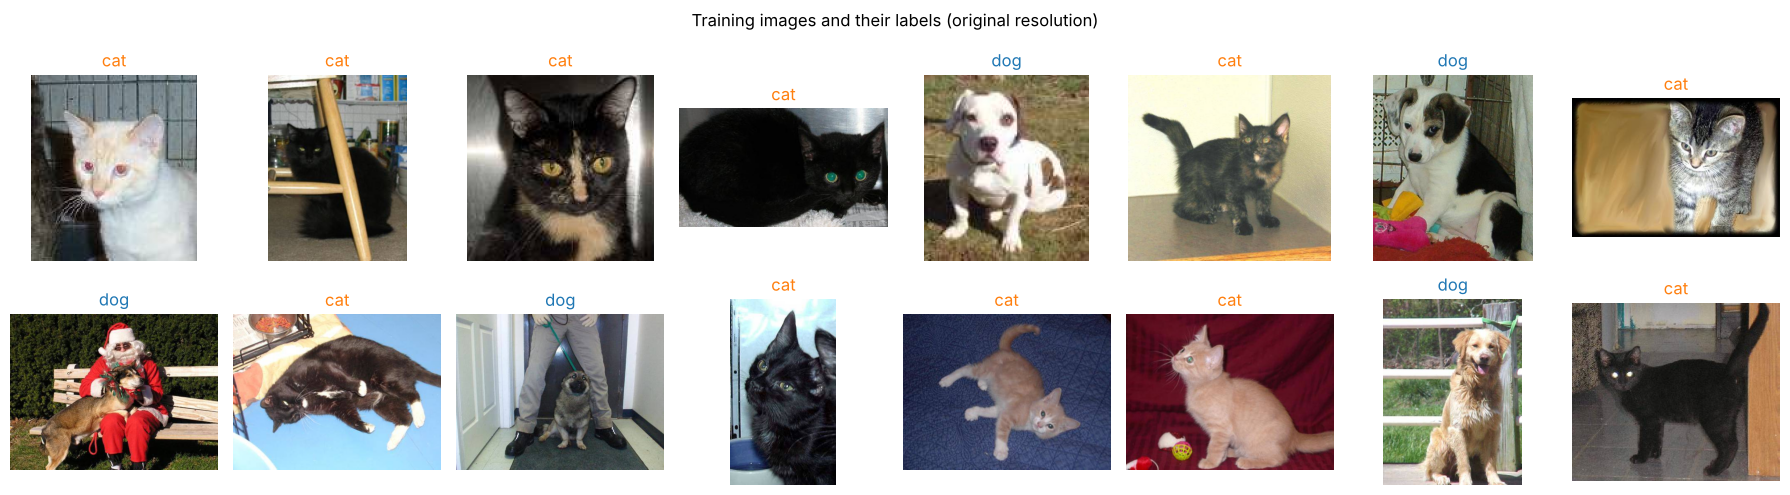

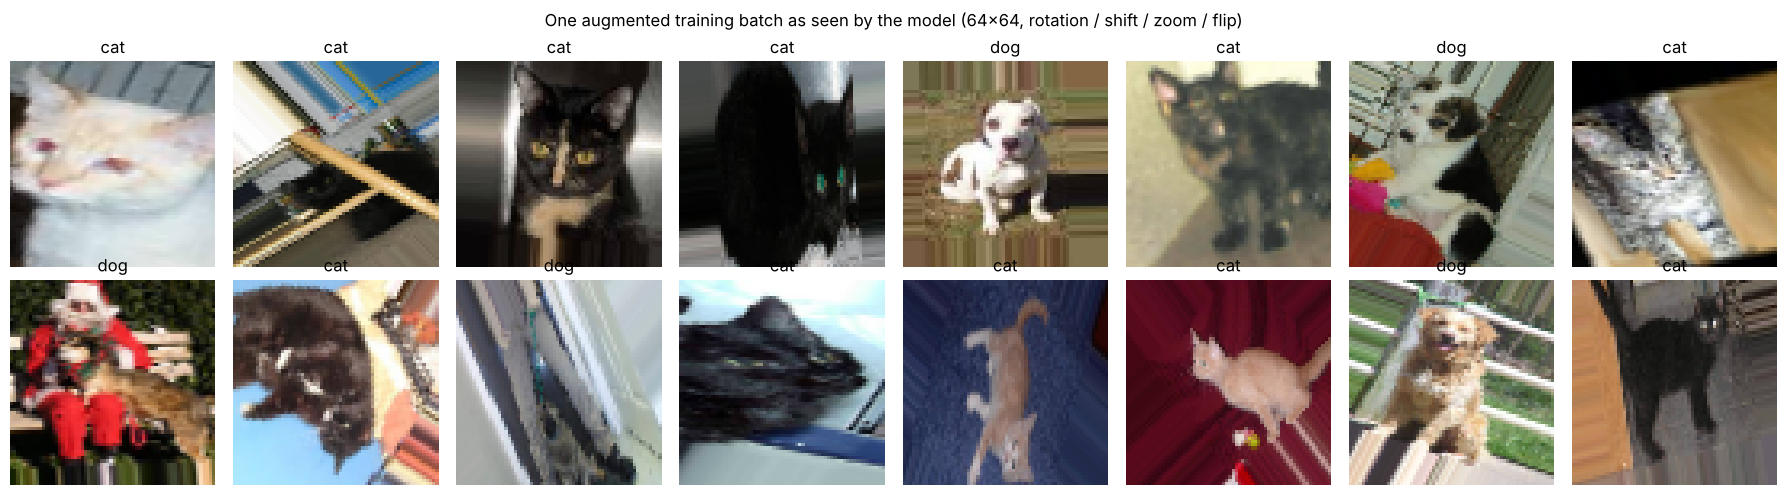

In [4]:
# Grid of training images (original files) annotated with their label
sample = df_tr.sample(16, random_state=seed)
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for ax, (_, row) in zip(axes.ravel(), sample.iterrows()):
    ax.imshow(Image.open(row['filepath']))
    ax.set_title(row['label'], color='tab:orange' if row['label'] == 'cat' else 'tab:blue', fontsize=12)
    ax.axis('off')
fig.suptitle('Training images and their labels (original resolution)')
plt.tight_layout(); plt.show()

# The same kind of images as the model sees them: 64x64, augmented
xb, yb = next(train_flow)
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for ax, img, lab in zip(axes.ravel(), xb, yb):
    ax.imshow(img)
    ax.set_title(idx_to_class[int(lab)], fontsize=12)
    ax.axis('off')
fig.suptitle('One augmented training batch as seen by the model (64x64, rotation / shift / zoom / flip)')
plt.tight_layout(); plt.show()

**Data report:**
- The labeled set has **25,000 images: 12,500 cats and 12,500 dogs**. After the stratified 80/20 split, the training generator has **20,000 images (10,000 per class)** and the validation generator **5,000 images (2,500 per class)**. `class_indices` maps `cat → 0` and `dog → 1`, so the sigmoid output of the model is the probability of *dog*.
- The classes are **perfectly balanced**, so accuracy is a meaningful metric and no class weights or resampling are needed (see Part 9).
- The **12,500 test images** are unlabeled and only used for the final predictions.
- **Sources of visual variability:** very different **poses** (sitting, lying, jumping, only the head visible), **scales** (close-up portrait vs. small animal in a large scene), **lighting** (flash, outdoor sun, dark rooms), **backgrounds** (sofas, grass, cages, people holding the animal), many **breeds and colours** (some dogs are small and fluffy like cats, some cats have dog-like colours), image sizes and aspect ratios (from about 50 to 500 pixels), and sometimes several animals, text or borders in the same picture.

**Visual cues that should help the model:** the **shape of the face** (cats have a short, round face with a small nose; dogs usually have a longer muzzle and a bigger, darker nose), the **ears** (cats have triangular, upright ears; many dogs have floppy or larger ears), the **eyes** (cats' eyes are larger relative to the face, often with slit pupils), whiskers, and the general body proportions. Fur colour and background are much less reliable: a model relying on them would learn biases (e.g. "grass = dog").

## 3. Define the model architecture

**Planned CNN:**
- **Three convolutional blocks** with **32, 64 and 128 filters** of size **3×3** and ReLU activation. The number of filters doubles at each block: the first layers detect simple local patterns (edges, colour contrasts, fur texture), the deeper ones combine them into more complex parts (eyes, ears, nose).
- A **2×2 MaxPooling** after each convolution, which halves the spatial size (64 → 31 → 14 → 6). Pooling reduces the number of parameters and the computation, and makes the detection of a pattern tolerant to small shifts (translational invariance).
- After **Flatten**, a **Dropout(0.5)** layer randomly switches off half of the features at each training step. This prevents the network from relying on a few specific pixels or co-adapted neurons, i.e. it regularises the model and reduces overfitting.
- A hidden **Dense(128, ReLU)** layer combines the features, followed by the output **Dense(1, sigmoid)** unit, which gives the probability that the image is a dog.

**Loss:** binary cross-entropy, the correct loss for a Bernoulli target (cat = 0 / dog = 1) with a sigmoid output.

In [5]:
from tensorflow.keras import layers, models

def build_model(dropout=0.5, learning_rate=1e-3):
    model = models.Sequential([
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dropout(dropout),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Choose the optimization setup

- **Optimizer: Adam.** It adapts the learning rate of each weight using running averages of the gradients and of their squares, so it converges quickly without much tuning, which is ideal for a first CNN.
- **Initial learning rate: 1e-3**, Adam's default. It is large enough to learn quickly in the first epochs and small enough to stay stable with batch-sized gradient estimates; if the validation loss plateaus, it will be reduced automatically.
- **Batch size: 32.** At 64×64×3 pixels, a batch takes less than 2 MB of input data plus the activations, which fits easily in CPU or GPU memory, and 32 gives a good balance between noisy (regularising) gradients and speed.
- **EarlyStopping** on the **validation loss** (patience 4, best weights restored): training stops when the validation loss has not improved for 4 epochs, before the model starts overfitting.
- **ReduceLROnPlateau** on the validation loss (factor 0.5, patience 2): when the validation loss stops improving, the learning rate is halved, which helps the model settle into a better minimum.

We monitor both the **loss** (smoother and more sensitive to the quality of the probabilities) and the **accuracy** (easier to interpret; reliable here since the classes are balanced).

## 5. Train the model

### 5.1 Fixed number of epochs (with augmentation)

Epoch 1/12


625/625 - 52s - 84ms/step - accuracy: 0.5901 - loss: 0.6626 - val_accuracy: 0.6140 - val_loss: 0.6231


Epoch 2/12


625/625 - 48s - 77ms/step - accuracy: 0.6604 - loss: 0.6100 - val_accuracy: 0.7358 - val_loss: 0.5248


Epoch 3/12


...

625/625 - 52s - 83ms/step - accuracy: 0.7481 - loss: 0.5048 - val_accuracy: 0.8110 - val_loss: 0.4076


Epoch 11/12


625/625 - 49s - 78ms/step - accuracy: 0.7570 - loss: 0.4944 - val_accuracy: 0.8136 - val_loss: 0.4089


Epoch 12/12


625/625 - 50s - 80ms/step - accuracy: 0.7609 - loss: 0.4889 - val_accuracy: 0.8196 - val_loss: 0.4056


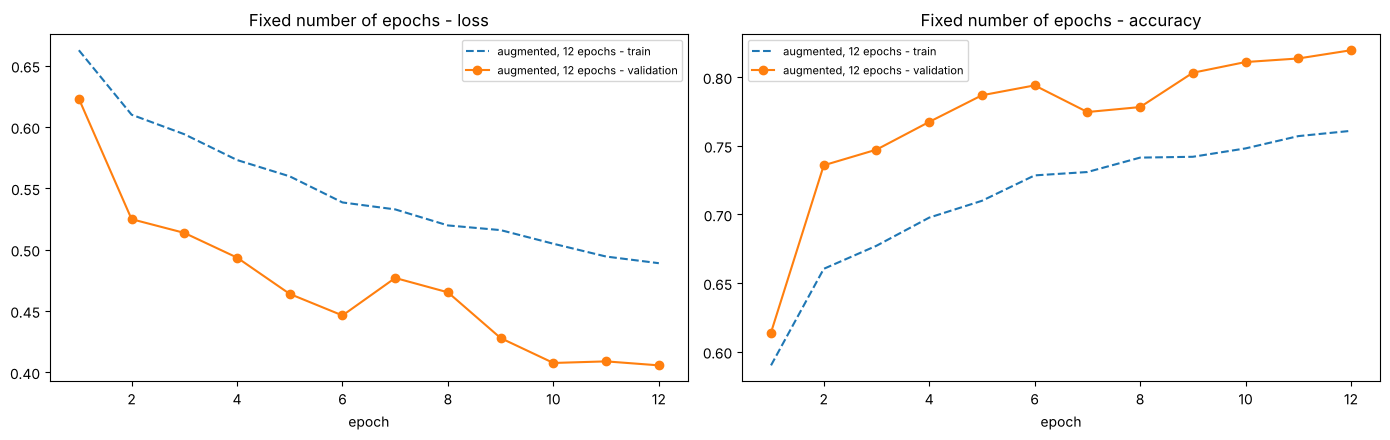

In [6]:
import time, json

def plot_history(histories, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for name, h in histories.items():
        ep = range(1, len(h['loss']) + 1)
        axes[0].plot(ep, h['loss'], '--', label=f'{name} - train')
        axes[0].plot(ep, h['val_loss'], 'o-', label=f'{name} - validation')
        axes[1].plot(ep, h['accuracy'], '--', label=f'{name} - train')
        axes[1].plot(ep, h['val_accuracy'], 'o-', label=f'{name} - validation')
    axes[0].set_title(f'{title} - loss'); axes[0].set_xlabel('epoch'); axes[0].legend(fontsize=8)
    axes[1].set_title(f'{title} - accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()

run_log = {}

tf.keras.utils.set_random_seed(42)
model_fixed = build_model()
t0 = time.time()
hist_fixed = model_fixed.fit(train_flow, validation_data=val_flow, epochs=12, verbose=2)
run_log['augmented_fixed_12_epochs'] = {'epochs': 12, 'time_s': round(time.time() - t0)}
plot_history({'augmented, 12 epochs': hist_fixed.history}, 'Fixed number of epochs')

### 5.2 Same model with EarlyStopping and ReduceLROnPlateau

Epoch 1/20


625/625 - 52s - 83ms/step - accuracy: 0.5518 - loss: 0.6838 - val_accuracy: 0.5430 - val_loss: 0.6765 - learning_rate: 0.0010


Epoch 2/20


625/625 - 51s - 81ms/step - accuracy: 0.6251 - loss: 0.6411 - val_accuracy: 0.6938 - val_loss: 0.5767 - learning_rate: 0.0010


Epoch 3/20


...

625/625 - 50s - 80ms/step - accuracy: 0.7837 - loss: 0.4575 - val_accuracy: 0.8304 - val_loss: 0.3763 - learning_rate: 5.0000e-04


Epoch 19/20


625/625 - 51s - 81ms/step - accuracy: 0.7833 - loss: 0.4534 - val_accuracy: 0.8214 - val_loss: 0.3766 - learning_rate: 5.0000e-04


Epoch 20/20


625/625 - 45s - 73ms/step - accuracy: 0.7872 - loss: 0.4503 - val_accuracy: 0.8388 - val_loss: 0.3625 - learning_rate: 5.0000e-04


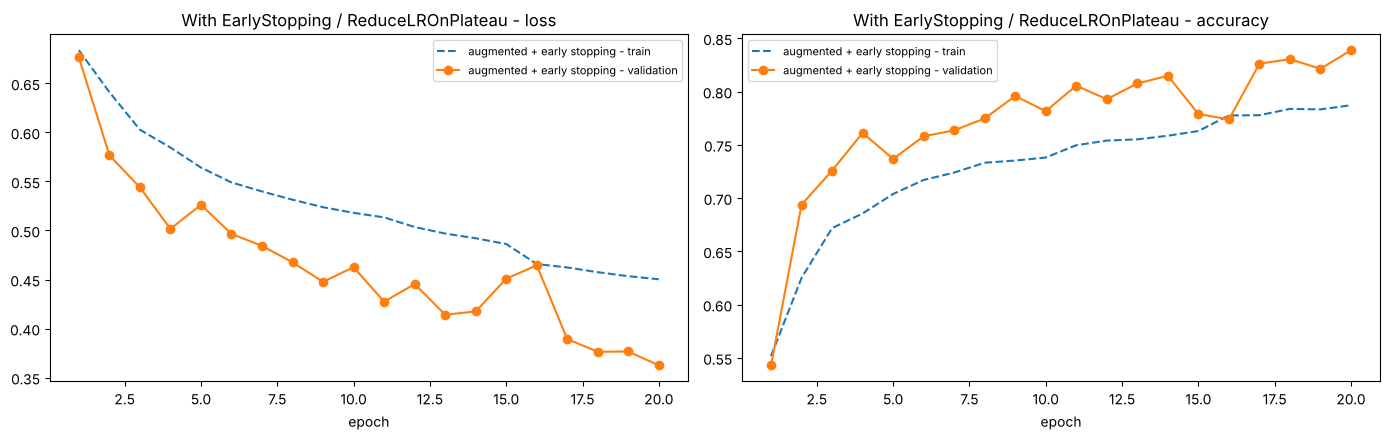

{'augmented_fixed_12_epochs': {'epochs': 12, 'time_s': 606}, 'augmented_early_stopping': {'epochs_run': 20, 'time_s': 988, 'best_epoch': 20}}


In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
os.makedirs("artifacts", exist_ok=True)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
    ModelCheckpoint('artifacts/best_model.keras', monitor='val_loss', save_best_only=True),
]

tf.keras.utils.set_random_seed(42)
model_aug = build_model()
t0 = time.time()
hist_aug = model_aug.fit(train_flow, validation_data=val_flow, epochs=20, callbacks=callbacks, verbose=2)
run_log['augmented_early_stopping'] = {'epochs_run': len(hist_aug.history['loss']), 'time_s': round(time.time() - t0),
                                       'best_epoch': int(np.argmin(hist_aug.history['val_loss'])) + 1}
plot_history({'augmented + early stopping': hist_aug.history}, 'With EarlyStopping / ReduceLROnPlateau')
print(run_log)

**Reading the curves:**
- **Fixed 12 epochs (augmented):** the training and validation losses decrease together (validation loss 0.62 → 0.41, validation accuracy 61% → 82%), with no sign of overfitting yet: the model is still improving when the 12 epochs end.
- **With EarlyStopping + ReduceLROnPlateau (augmented, up to 20 epochs):** the validation loss oscillates a little (e.g. epochs 15–16), so ReduceLROnPlateau halves the learning rate to 5e-4 after epoch 16; the validation loss then drops again to its best value **0.363 (83.9% accuracy) at epoch 20**. Early stopping never triggered: the best epoch is the last one, so this model is still **slightly underfitting** and would benefit from more epochs.
- Interestingly, the **validation accuracy is higher than the training accuracy** (84% vs 79%) during the whole training. This is a normal effect of strong augmentation (rotations up to 45°, 50% zoom) and dropout: the training images are made harder on purpose, while the validation images are clean.

**How we detect overfitting:** the warning sign is a **divergence** of the curves: the training loss keeps decreasing while the validation loss stops decreasing or goes back up, and the train/validation accuracy gap grows. We do not see it with augmentation, but we see it clearly without augmentation (Part 8). **Mitigation:** early stopping with `restore_best_weights` (keeps the model before overfitting), stronger augmentation, more dropout, or a smaller model.

## 6. Evaluate on validation data

Validation loss: 0.3625 | validation accuracy: 0.8388


              precision    recall  f1-score   support

         cat     0.8686    0.7984    0.8320      2500
         dog     0.8135    0.8792    0.8451      2500

    accuracy                         0.8388      5000
   macro avg     0.8410    0.8388    0.8385      5000
weighted avg     0.8410    0.8388    0.8385      5000



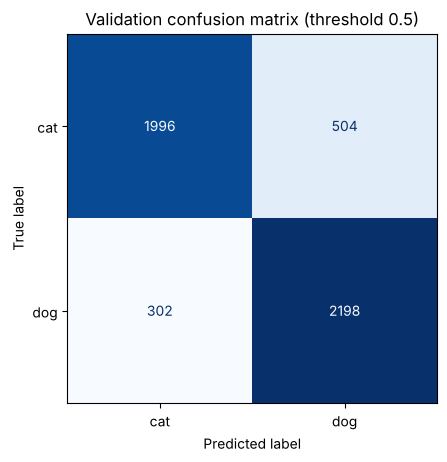

Cats predicted as dogs: 504 | dogs predicted as cats: 302


In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

val_loss, val_acc = model_aug.evaluate(val_flow, verbose=0)
print(f"Validation loss: {val_loss:.4f} | validation accuracy: {val_acc:.4f}")

val_prob = model_aug.predict(val_flow, verbose=0).ravel()   # P(dog); val_flow is not shuffled
y_val = np.array(val_flow.labels)
val_pred = (val_prob >= 0.5).astype(int)

print(classification_report(y_val, val_pred, target_names=['cat', 'dog'], digits=4))
cm = confusion_matrix(y_val, val_pred)
ConfusionMatrixDisplay(cm, display_labels=['cat', 'dog']).plot(cmap='Blues', colorbar=False)
plt.title('Validation confusion matrix (threshold 0.5)')
plt.show()
print(f"Cats predicted as dogs: {cm[0, 1]} | dogs predicted as cats: {cm[1, 0]}")

,accuracy,cats -> dog,dogs -> cat
threshold,,,
0.300000,0.7888,946,110
0.400000,0.8182,714,195
0.500000,0.8388,504,302
0.600000,0.8396,360,442
0.700000,0.8260,233,637


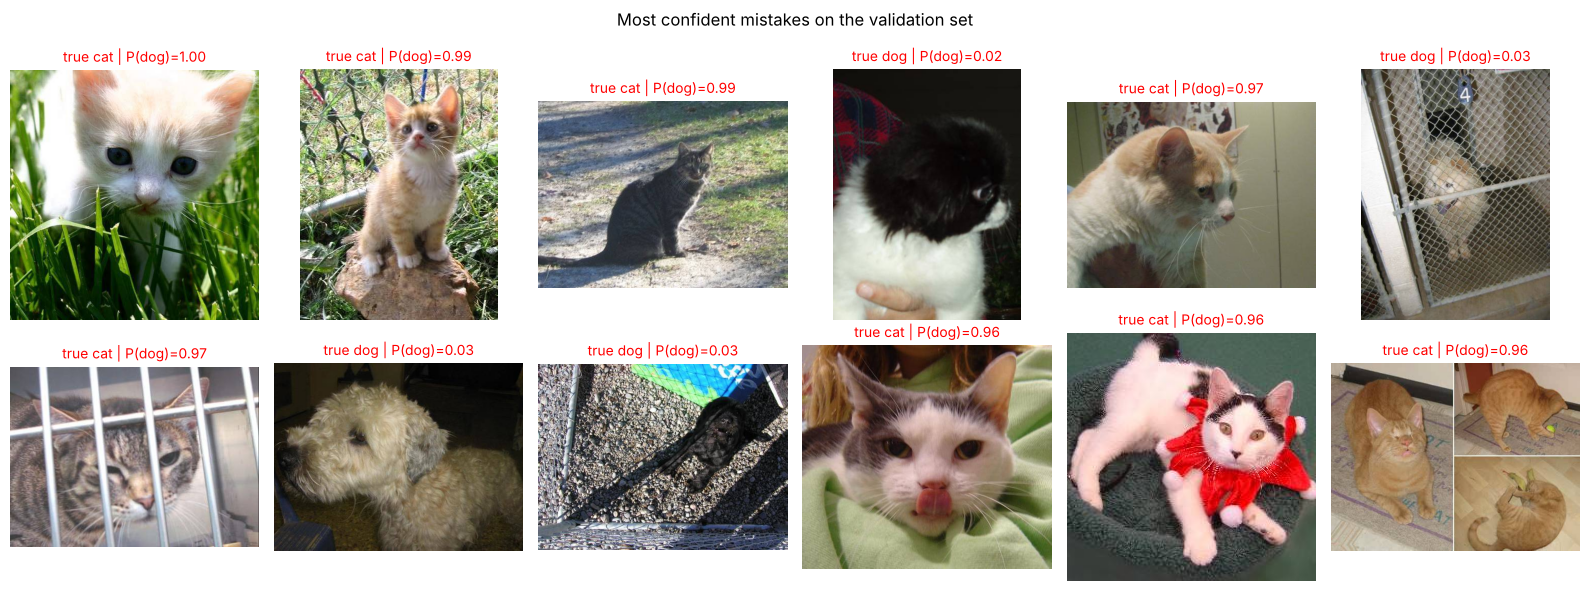

In [9]:
# Effect of the decision threshold
rows = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    p = (val_prob >= t).astype(int)
    c = confusion_matrix(y_val, p)
    rows.append({'threshold': t, 'accuracy': (p == y_val).mean(), 'cats -> dog': c[0, 1], 'dogs -> cat': c[1, 0]})
thr_df = pd.DataFrame(rows).set_index('threshold')
display(thr_df.style.format({'accuracy': '{:.4f}'}))

# Some misclassified validation images
wrong = np.where(val_pred != y_val)[0]
order = wrong[np.argsort(-np.abs(val_prob[wrong] - 0.5))][:12]  # most confident mistakes
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for ax, k in zip(axes.ravel(), order):
    ax.imshow(Image.open(df_val['filepath'].iloc[k]))
    ax.set_title(f"true {idx_to_class[y_val[k]]} | P(dog)={val_prob[k]:.2f}", fontsize=10, color='red')
    ax.axis('off')
fig.suptitle('Most confident mistakes on the validation set')
plt.tight_layout(); plt.show()

**Validation results (augmented model, threshold 0.5):** accuracy **83.9%**, loss **0.362**.

| Class | Precision | Recall | F1 |
|---|---|---|---|
| cat | 0.869 | 0.798 | 0.832 |
| dog | 0.814 | 0.879 | 0.845 |

- **The dominant error is "cat predicted as dog": 504 cats vs 302 dogs misclassified.** The model is biased towards *dog*: it finds 88% of the dogs but only 80% of the cats, and when it says "dog" it is right only 81% of the time.
- The most confident mistakes show why: **ginger, cream or white cats** are often predicted as dogs (colours more frequent among dogs in this dataset), kittens in grass or outdoor scenes too, while **black or dark dogs photographed in low light**, curly white dogs or dogs behind cage bars are predicted as cats. At 64×64 pixels the face details are blurred, so the model relies partly on **colour, texture and background**, which is exactly the kind of bias described in the instructions.
- **Threshold choice:** moving the threshold changes the balance between the two errors. At 0.6, the errors become balanced (360 cats → dog vs 442 dogs → cat) and the accuracy is about the same (84.0% vs 83.9%). Since both errors have the same cost here, 0.5 or 0.6 are both reasonable; we keep 0.5 for the test predictions (the gain at 0.6 is within noise). If the goal were to miss as few cats as possible, we would raise the threshold.
- **Augmentation needs:** colour augmentation (brightness, contrast, hue shifts) would reduce the colour bias, and a higher resolution would let the model see faces, ears and noses more clearly.

## 7. Run inference on the unlabeled test set

(12500, 3)


,filepath,prob_dog,pred_label
0,data/cats_dogs/test/test/11433.jpg,0.02744,cat
1,data/cats_dogs/test/test/645.jpg,0.95258,dog
2,data/cats_dogs/test/test/3899.jpg,0.95233,dog
3,data/cats_dogs/test/test/12177.jpg,0.99461,dog
4,data/cats_dogs/test/test/1246.jpg,0.26235,cat


pred_label
dog    0.547
cat    0.453
Name: proportion, dtype: float64


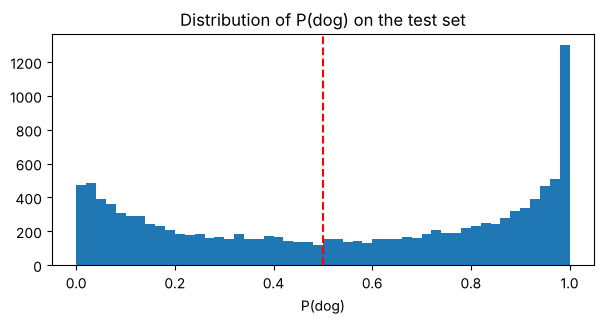

In [10]:
THRESHOLD = 0.5   # balanced classes and balanced errors on validation -> keep 0.5 (see Part 6)

test_flow.reset()
test_prob = model_aug.predict(test_flow, verbose=0).ravel()
predictions = pd.DataFrame({
    'filepath': df_test_full['filepath'].values,
    'prob_dog': test_prob.round(5),
    'pred_label': np.where(test_prob >= THRESHOLD, 'dog', 'cat'),
})
predictions.to_csv('test_predictions.csv', index=False)
print(predictions.shape)
display(predictions.head())
print(predictions['pred_label'].value_counts(normalize=True).round(3))

plt.figure(figsize=(7, 3))
plt.hist(test_prob, bins=50)
plt.axvline(THRESHOLD, color='red', ls='--')
plt.title('Distribution of P(dog) on the test set'); plt.xlabel('P(dog)')
plt.show()

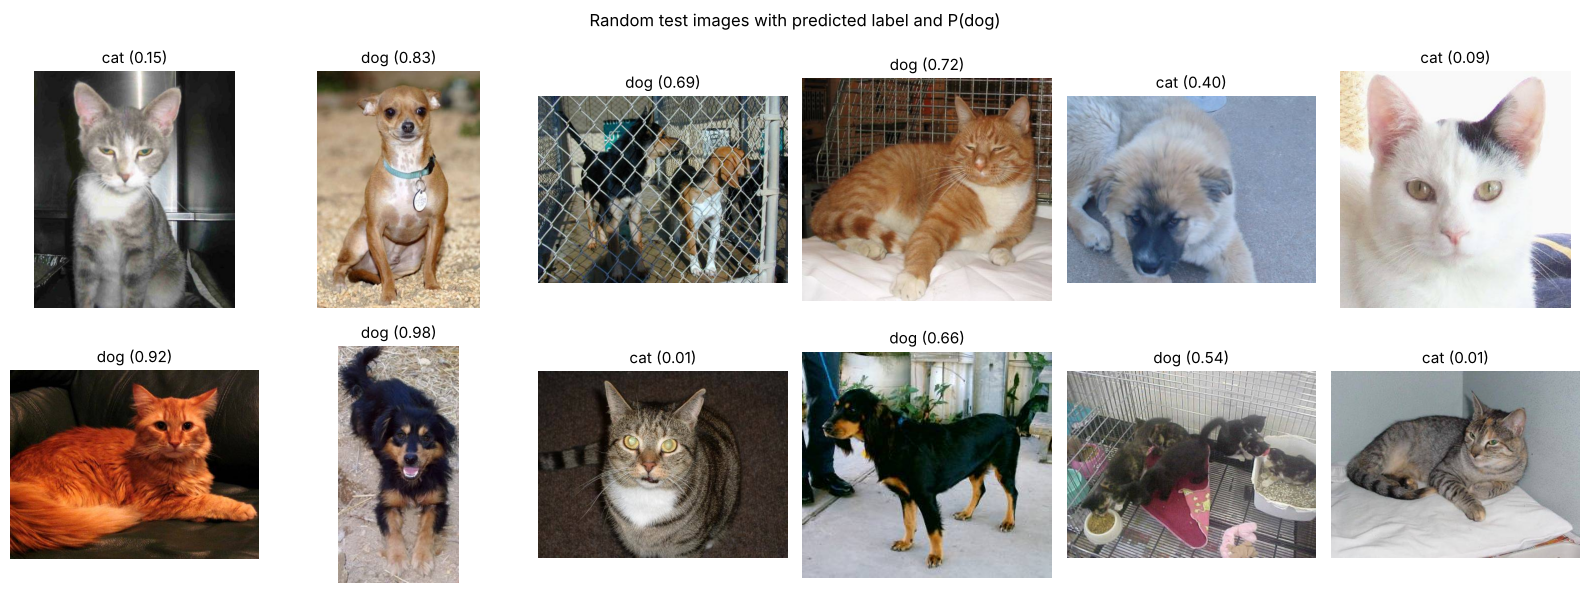

In [11]:
# Manual sanity check: random test images with their prediction
check = predictions.sample(12, random_state=0)
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for ax, (_, row) in zip(axes.ravel(), check.iterrows()):
    ax.imshow(Image.open(row['filepath']))
    ax.set_title(f"{row['pred_label']} ({row['prob_dog']:.2f})", fontsize=11)
    ax.axis('off')
fig.suptitle('Random test images with predicted label and P(dog)')
plt.tight_layout(); plt.show()

**Test predictions:** the 12,500 test images are classified with the threshold **0.5** (classes balanced, errors on validation roughly balanced, no reason to favour one class). The model predicts **54.7% dogs and 45.3% cats**, consistent with its slight bias towards *dog* on the validation set. The predictions are saved in **`test_predictions.csv`** with the columns `filepath`, `prob_dog` and `pred_label`; the file path makes it possible to open any image again for error analysis.

**How to check a subset manually:** take a **random sample** of the CSV (like the 12 images above), open each image from its `filepath` and compare with the predicted label; then look specifically at the **most uncertain predictions** (`prob_dog` close to 0.5) and at the **most confident ones** of each class, which reveal systematic errors. In the random sample above, 8 of the 12 predictions are correct; the errors are two ginger cats predicted as dogs, a puppy predicted as a cat and a cage with several kittens (P(dog) = 0.54), consistent with the error analysis on the validation set. Counting the errors on a larger labeled sample (e.g. 100 images) gives an estimate of the real test accuracy.

## 8. Compare baseline vs augmentation

Same architecture, same optimisation setup and callbacks, but the training generator only rescales the images (no rotation, shift, zoom or flip).

Found 20000 non-validated image filenames belonging to 2 classes.


Epoch 1/20


625/625 - 34s - 55ms/step - accuracy: 0.6626 - loss: 0.6013 - val_accuracy: 0.7458 - val_loss: 0.5129 - learning_rate: 0.0010


Epoch 2/20


625/625 - 32s - 52ms/step - accuracy: 0.7751 - loss: 0.4717 - val_accuracy: 0.8194 - val_loss: 0.4053 - learning_rate: 0.0010


...

625/625 - 31s - 50ms/step - accuracy: 0.9321 - loss: 0.1658 - val_accuracy: 0.8746 - val_loss: 0.3202 - learning_rate: 5.0000e-04


Epoch 12/20


625/625 - 30s - 49ms/step - accuracy: 0.9474 - loss: 0.1328 - val_accuracy: 0.8834 - val_loss: 0.3094 - learning_rate: 2.5000e-04


Epoch 13/20


625/625 - 32s - 51ms/step - accuracy: 0.9505 - loss: 0.1254 - val_accuracy: 0.8786 - val_loss: 0.3198 - learning_rate: 2.5000e-04


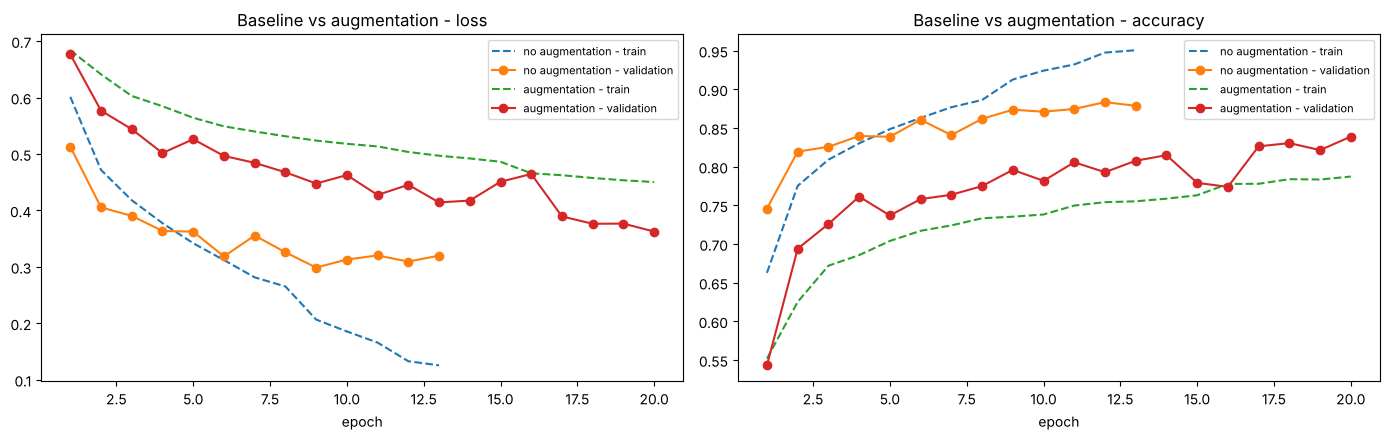

In [12]:
plain_gen = ImageDataGenerator(rescale=1./255)
train_flow_plain = plain_gen.flow_from_dataframe(
    df_tr, x_col="filepath", y_col="label", target_size=(IMG_HEIGHT, IMG_WIDTH),
    class_mode="binary", batch_size=batch_size, shuffle=True, seed=seed, validate_filenames=False)

tf.keras.utils.set_random_seed(42)
model_base = build_model()
t0 = time.time()
hist_base = model_base.fit(train_flow_plain, validation_data=val_flow, epochs=20, verbose=2, callbacks=[
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)])
run_log['baseline_no_augmentation'] = {'epochs_run': len(hist_base.history['loss']), 'time_s': round(time.time() - t0),
                                       'best_epoch': int(np.argmin(hist_base.history['val_loss'])) + 1}
plot_history({'no augmentation': hist_base.history, 'augmentation': hist_aug.history}, 'Baseline vs augmentation')

In [13]:
def summary_row(h, model):
    i = int(np.argmin(h['val_loss']))
    loss, acc = model.evaluate(val_flow, verbose=0)
    return {'best epoch': i + 1, 'train acc (best epoch)': h['accuracy'][i], 'val acc': acc, 'val loss': loss,
            'generalization gap': h['accuracy'][i] - acc}

compare = pd.DataFrame({'no augmentation': summary_row(hist_base.history, model_base),
                        'augmentation': summary_row(hist_aug.history, model_aug)}).T
display(compare.style.format({'best epoch': '{:.0f}', 'train acc (best epoch)': '{:.4f}', 'val acc': '{:.4f}',
                              'val loss': '{:.4f}', 'generalization gap': '{:+.4f}'}))

,best epoch,train acc (best epoch),val acc,val loss,generalization gap
no augmentation,9,0.9126,0.8736,0.2987,+0.0390
augmentation,20,0.7872,0.8388,0.3625,-0.0516


**Results (same architecture, same optimizer and callbacks, at most 20 epochs):**

| Model | Best epoch | Train acc (best epoch) | Val acc | Val loss | Generalization gap |
|---|---|---|---|---|---|
| No augmentation | 9 | 0.913 | **0.874** | **0.299** | +3.9 points |
| Augmentation | 20 | 0.787 | 0.839 | 0.362 | −5.2 points |

- **Without augmentation, the model learns much faster** and reaches a better validation accuracy within our budget (87.4% at epoch 9). But its curves show **clear overfitting**: the training accuracy keeps climbing to 95% and the training loss falls to 0.13, while the validation loss stops improving after epoch 9 (0.30 → 0.32). Early stopping ended this run after 13 epochs and restored the weights of epoch 9.
- **With augmentation, there is no overfitting at all** (negative gap: the model does better on the clean validation images than on the augmented training images), but the strong transformations (45° rotations, 50% zoom) make the task harder, so the model learns more slowly and was still improving after 20 epochs. Within the same epoch budget it therefore ends **3.5 points below** the baseline.
- **Analysis of the generalization gap:** augmentation does what it is meant to do (closing the gap between training and validation), but here the limiting factor is not overfitting, it is the **training time** and the **low resolution**. With more epochs (or a GPU), the augmented model should keep improving and overtake the baseline, which has already reached its limit; a lighter augmentation (rotation ±15°, zoom 0.2) would also be a better compromise for 64×64 images. This ablation shows that augmentation is not automatically better: its strength must be matched to the training budget.

## 9. Class imbalance handling

The classes are **perfectly balanced** (10,000 cats and 10,000 dogs in the training split), so the balanced class weights computed below are exactly 1.0 for both classes: using `class_weight` would give the same loss as without it, so retraining is not necessary.

In [14]:
from sklearn.utils.class_weight import compute_class_weight
weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=np.array(train_flow.labels))
class_weight = {i: float(w) for i, w in enumerate(weights)}
print("Balanced class weights:", class_weight)
# If they were different, we would retrain with:
# model.fit(train_flow, validation_data=val_flow, epochs=..., class_weight=class_weight)

Balanced class weights: {0: 1.0, 1: 1.0}


If one class were rare (e.g. 20% cats), its errors would only count for a small part of the loss, so the network would favour the majority class: high recall for dogs, low recall for cats. With `class_weight`, each cat image would count more (weight = n_samples / (2 × n_cats)), which **increases the recall of the minority class** (more cats found), usually at the cost of a slightly lower **precision** for that class (some dogs predicted as cats).

## 10. Save artifacts for reuse

In [15]:
model_aug.save('artifacts/cats_dogs_cnn.h5')        # HDF5 format
# artifacts/best_model.keras was already saved by ModelCheckpoint during training (native Keras format)

config = {
    'image_size': [IMG_HEIGHT, IMG_WIDTH], 'batch_size': batch_size, 'seed': seed,
    'class_indices': train_flow.class_indices, 'output': 'sigmoid = P(dog)', 'threshold': THRESHOLD,
    'split': {'train': train_flow.samples, 'validation': val_flow.samples, 'test': test_flow.samples},
    'augmentation': {'rotation_range': 45, 'width_shift_range': 0.15, 'height_shift_range': 0.15,
                     'zoom_range': 0.5, 'horizontal_flip': True, 'rescale': '1/255'},
    'architecture': 'Conv32-Pool-Conv64-Pool-Conv128-Pool-Flatten-Dropout0.5-Dense128-Dense1(sigmoid)',
    'optimizer': {'name': 'adam', 'learning_rate': 1e-3},
    'callbacks': ['EarlyStopping(val_loss, patience=4)', 'ReduceLROnPlateau(val_loss, factor=0.5, patience=2)'],
    'results': {'val_accuracy': float(val_acc), 'val_loss': float(val_loss)},
    'runs': run_log,
    'tensorflow_version': tf.__version__,
}
with open('artifacts/training_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print(json.dumps(config, indent=2))

reloaded = tf.keras.models.load_model('artifacts/cats_dogs_cnn.h5')
print("Reloaded model - validation accuracy:", round(reloaded.evaluate(val_flow, verbose=0)[1], 4))
print("Saved files:", os.listdir('artifacts'))

{
  "image_size": [
    64,
    64
  ],
  "batch_size": 32,
  "seed": 1337,
  "class_indices": {
    "cat": 0,
    "dog": 1
  },
  "output": "sigmoid = P(dog)",
  "threshold": 0.5,
  "split": {
    "train": 20000,
    "validation": 5000,
    "test": 12500
  },
  "augmentation": {
    "rotation_range": 45,
    "width_shift_range": 0.15,
    "height_shift_range": 0.15,
    "zoom_range": 0.5,
    "horizontal_flip": true,
    "rescale": "1/255"
  },
  "architecture": "Conv32-Pool-Conv64-Pool-Conv128-Pool-Flatten-Dropout0.5-Dense128-Dense1(sigmoid)",
  "optimizer": {
    "name": "adam",
    "learning_rate": 0.001
  },
  "callbacks": [
    "EarlyStopping(val_loss, patience=4)",
    "ReduceLROnPlateau(val_loss, factor=0.5, patience=2)"
  ],
  "results": {
    "val_accuracy": 0.8388000130653381,
    "val_loss": 0.3624894917011261
  },
  "runs": {
    "augmented_fixed_12_epochs": {
      "epochs": 12,
      "time_s": 606
    },
    "augmented_early_stopping": {
      "epochs_run": 20,
      "ti

Reloaded model - validation accuracy: 0.8388
Saved files: ['best_model.keras', 'cats_dogs_cnn.h5', 'training_config.json']


**Why save both the weights and the metadata?** The model file alone is not enough to reproduce the results or to use the model correctly: we also need to know the **input size** (64×64), the **preprocessing** (pixels divided by 255), the **meaning of the output** (`cat = 0`, `dog = 1`, so the sigmoid gives P(dog)) and the **threshold**. Recording the augmentation, the optimizer, the callbacks, the data split and the library version makes it possible to retrain the same model later, compare new experiments fairly, and audit how a deployed model was produced.

## 11. Extensions

**Proposed extension: transfer learning with a frozen MobileNetV2 backbone.** MobileNetV2 was pre-trained on ImageNet (1.2 million images, including many cat and dog breeds), so its convolutional layers already detect edges, fur textures, eyes, ears and muzzles. We would use it as a frozen feature extractor (`include_top=False`, input at least 96×96 or 128×128), add a small head (`GlobalAveragePooling2D → Dropout → Dense(1, sigmoid)`) and train only this head, then optionally fine-tune the last blocks with a small learning rate.

**Expected benefit:** a much higher accuracy (typically more than 95% on Cats vs Dogs, against 84–87% for our small CNN trained from scratch at 64×64), in fewer epochs, because the network does not need to learn low-level visual features from only 20,000 images. MobileNetV2 is lightweight (about 2.3 million parameters), so it stays fast enough for a CPU/VM. **Batch Normalization** after the convolutions would also stabilise and speed up the training of our own CNN, and **mixed precision** would mainly speed up training on a modern GPU, without improving the accuracy.

## 12. Deliverables checklist and run log

- ✅ **Data report** with class counts (12,500 cats / 12,500 dogs; 20,000 train, 5,000 validation, 12,500 test) and sample grids (Part 2).
- ✅ **Model description and optimisation rationale** in prose (Parts 3 and 4).
- ✅ **Training and validation curves** with interpretation (Parts 5 and 8).
- ✅ **Validation metrics:** accuracy 83.9%, loss 0.362, confusion matrix, precision and recall per class, threshold analysis (Part 6).
- ✅ **Test predictions CSV:** `test_predictions.csv` (12,500 rows: `filepath`, `prob_dog`, `pred_label`) (Part 7).
- ✅ **Saved model** (`artifacts/cats_dogs_cnn.h5`, plus `artifacts/best_model.keras` from the checkpoint) and **run log / configuration** (`artifacts/training_config.json`) (Part 10).

**Run log (CPU):**

| Run | Epochs | Time | Best val accuracy |
|---|---|---|---|
| Augmented, fixed 12 epochs | 12 | 10 min | 82.0% |
| Augmented + EarlyStopping + ReduceLROnPlateau | 20 (best = 20) | 16.5 min | 83.9% |
| No augmentation (baseline) + same callbacks | 13 (best = 9) | 7 min | 87.4% |

**Conclusion:** a small 3-block CNN trained from scratch on 64×64 images reaches about **84–87% validation accuracy** on Cats vs Dogs. Augmentation removes overfitting but needs more epochs to pay off, and the remaining errors (light-coloured cats, dark dogs) show a colour/background bias that higher resolution, colour augmentation and above all **transfer learning** (Part 11) would reduce.